# Load mean, fit kernel on the residuals
advantage: regularize independently

In [1]:
# restart kernel
from IPython.core.display import HTML
HTML("<script>Jupyter.notebook.kernel.restart()</script>")

import math, random, pickle, os, copy, itertools, sys, gpytorch
import torch, logging, scipy.io
import numpy as np
import pandas as pd
import seaborn as sns
from numpy import random
from datetime import datetime

import matplotlib.pyplot as plt
from collections.abc import Iterable
%matplotlib inline

BASE_DIR = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.insert(1, BASE_DIR)

import config
config.init()
from config import device
from utils_pv import visualize_env
from utils.analyze_results import *
from utils.assistive_functions import load_trained_models, softplus_inverse
from utils.pf_scheduler import PriorFactorScheduler
from utils.train_models import train_models

random_seed = 5
random.seed(random_seed)
np.random.seed(random_seed)
random_state = np.random.RandomState(random_seed)

if torch.cuda.is_available() and not str(device)=='cpu':
    print('[INFO] running on GPU core ' + str(torch.cuda.current_device()))
else:
    print('[WARN] running on CPU')
#import platform
#platform.platform()

[INFO] running on GPU core 3


In [2]:
exp_name = 'PV_UniModal'         # PV_BiModal, PV_UniModal_augmented', PV_UniModal
mode = 'ours'            # ours or meta_fedavg

ts_data = False
scenario_name_fl = 'sml'
criteria = ['rsmse']
methods = [
    'resgp_nn32_nn44', 'resgp_nn32_nn16', 'resgp_nn32_nn32', 'resgp_nn32_nn4444', 'resgp_nn32_nn16x4', 'resgp_nn32_nn64',
    'resgp_lingp_nn22', 'resgp_lingp_nn44', 'resgp_lingp_nn16', 'resgp_lingp_nn32', 'resgp_lingp_nn4444',
    'resgp_nn22_nn22', 'resgp_nn22_nn44',
    'resgp_nn44_nn44', 'resgp_nn44_nn16', 'resgp_nn44_nn32', 'resgp_nn44_nn4444', 
    'resgp_nn16x4_nn16', 'resgp_nn16x4_nn32',
    'resgp_nn4x4_nn4x2', 'resgp_nn4x4_nn4x4', 'resgp_nn4x4_nn16x2', 
    # fix noise
    'resgp_nn32_nn16_fixnoise2', 'resgp_nn32_nn16_fixnoise4', 'resgp_nn32_nn16_fixnoise6',
    'resgp_nn16x4_nn16_fixnoise2', 'resgp_nn16x4_nn16_fixnoise4', 'resgp_nn16x4_nn16_fixnoise6', 'resgp_nn16x4_nn16_fixnoise8', 
    'resgp_nn16x4_nn32_fixnoise2', 'resgp_nn16x4_nn32_fixnoise4', 'resgp_nn16x4_n32_fixnoise6', 'resgp_nn32x4_nn16_fixnoise8'   
] 
methods_to_run = [
] 

assert mode == 'ours'

# Load data
* vary the tilt of the installation and the azimuthal orientation
* same coordinates and altitude of central Lausanne

In [3]:
# ------ LOAD DATA ------
# NOTE: env generated in notebook 1_visualization
filename_env = config.PVDATA_DIR + '/'+ exp_name+"_env"
file = open(filename_env, 'rb')
env_dict = pickle.load(file)
msg = '[INFO] loaded data for {:2.0f} clients'.format(env_dict['num_clients'])
print(msg)
file.close()
num_clients = env_dict['num_clients'] 
print('\n'+env_dict['info'])

# ----- SELECT A SUBSET OF CLIENTS -----
clients_subset= [12, 14, 15, 17, 22]
print('Subset of clients for demonstration: ', clients_subset)

num_features = len(env_dict['feature_names'])
print('\n[INFO] {:2.0f} features: '.format(
    len(env_dict['feature_names'])), *env_dict['feature_names'])
    

[INFO] loaded data for 24 clients

24 households at Lausanne - tilt_std: 5.0, az_std: 15.0, weather_dev: 0.1, irrad_std: 0.2, altitude_dev: 0.1, shadow_peak_red: 0.8, different module_name, different inverter_name, 
Subset of clients for demonstration:  [12, 14, 15, 17, 22]

[INFO] 15 features:  H_sun T2m WS10m station_irrad_direct_prev lag 1 lag 2 lag 4 lag 18 lag 20 lag 22 lag 43 lag 70 lag 74 lag 121 lag 145


# Step 1: load mean model and compute residuals

In [4]:
if len(methods_to_run)>0:
    assert len(methods_to_run)==1
    method_to_run = methods_to_run[0]
    assert method_to_run.startswith('resgp')
    mean_method = method_to_run.split('_')[1]
    covar_method = method_to_run.split('_')[2]

    # ---------- Load Mean Model from Global ----------
    filename_res = os.path.join(os.getcwd(), "saved_results", exp_name, 'global') # NOTE
    model_mean, _ = load_trained_models(
        mode='ours', methods=[mean_method], ts_data=ts_data,
        filename_res=filename_res+'_'+scenario_name_fl)

    model_mean = model_mean[mean_method][scenario_name_fl]['rsmse'] # NOTE: picl the best model based on RSMSE


In [5]:
# compute residuals
if len(methods_to_run)>0:
    env_dict_res = copy.deepcopy(env_dict)

    # calculate residuals if the mean model is not zero

    del env_dict_res['train_scenarios'][scenario_name_fl]['time_series']
    res_train_std, res_valid_std = np.zeros(num_clients), np.zeros(num_clients)
    res_train_mean, res_valid_mean = np.zeros(num_clients), np.zeros(num_clients)
    for client_num in np.arange(num_clients):
        x_train, y_train, x_valid, y_valid = env_dict['train_scenarios'][scenario_name_fl]['clients_data'][client_num]
        # x_train, y_train = _handle_input_dimensionality(x_train, y_train)
        # x_valid, y_valid = _handle_input_dimensionality(x_valid, y_valid)
        
        # residual of train
        y_train_pred, _ = model_mean.predict(x_train, y_train, x_train)
        y_valid_pred, _ = model_mean.predict(x_train, y_train, x_valid)
        y_train_pred = y_train_pred.reshape(y_train.shape)
        y_valid_pred = y_valid_pred.reshape(y_valid.shape)
        data_tup = (x_train, 
                    y_train-y_train_pred,
                    x_valid,
                    y_valid-y_valid_pred)

        env_dict_res['train_scenarios'][scenario_name_fl]['clients_data'][client_num] = data_tup

    # plot: can see bi-modality in residuals 
    # TODO: add labels and titles, normalize before plotting
    num_days = 7
    num_modes = env_dict['num_modes']
    fig, axs = plt.subplots(2, 1, figsize=(40,10*2))
    # fig, axs = plt.subplots(2*num_modes, 1, figsize=(40,10*2))
    clients_res = env_dict_res['train_scenarios']['1y']['clients_data']

    inds_plot = np.arange(num_days*len(env_dict_res['hours'])+1)

    client_num = 0
    colors = ['b', 'g']
    for mode_num in np.arange(num_modes):
        for _ in np.arange(env_dict_res['num_clients_per_mode'][mode_num]): # TODO
            x_train, res_train, x_valid, res_valid = clients_res[client_num]
            assert len(res_valid) >= len(inds_plot)
            axs[0].plot(res_valid[inds_plot], c=colors[mode_num])
            axs[1].plot(res_train[inds_plot], c=colors[mode_num])
            
            # axs[2*mode_num].plot(res_valid[inds_plot])
            # axs[2*mode_num+1].plot(res_train[inds_plot])
            client_num += 1
        
    day_sts = len(env_dict_res['hours']) * np.arange(num_days)
    for ax in axs:
        ax.set_xlabel('time')
        ax.set_ylabel('residual')
        for day_st in day_sts[:-1]:
            ax.axvline(day_st, ymin=0, ymax=1, color='black', linestyle='dashed')
        ax.axvline(day_sts[-1], ymin=0, ymax=1, color='black', linestyle='dashed', label='day start')
        ax.legend()
    axs[0].set_title('residuals of the shared ' + mean_method + ' mean on validation set')
    axs[1].set_title('residuals of the shared ' + mean_method + ' mean on train set')
    plt.tight_layout()
    plt.show()
    



# fit kernel

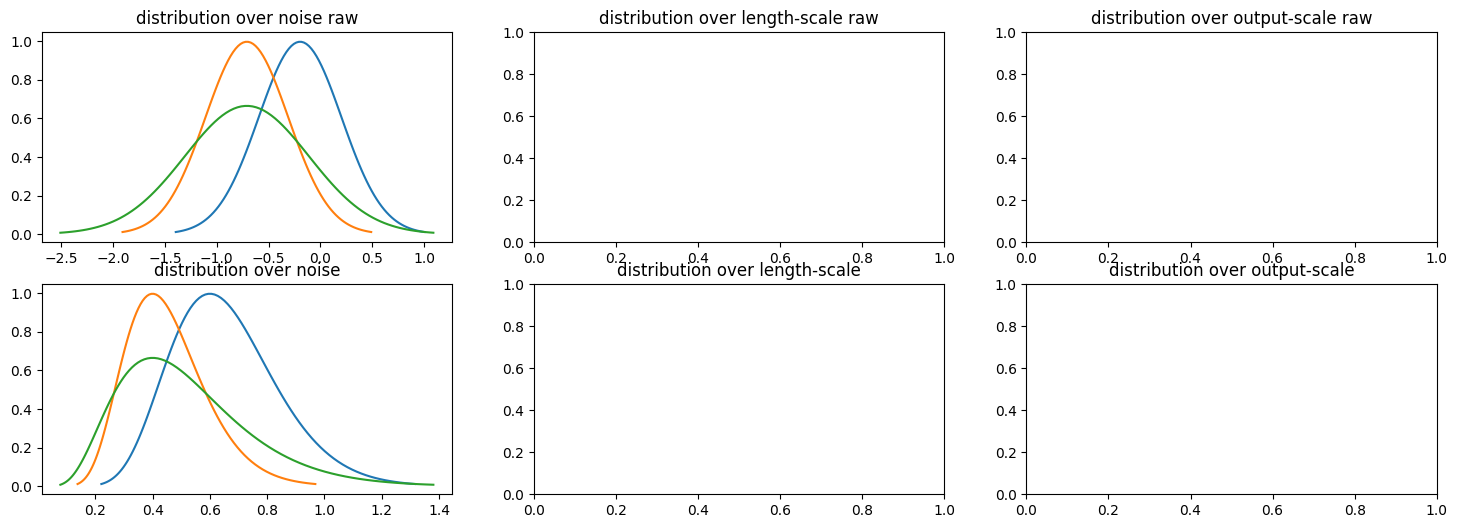

In [6]:
hyper_prior_dicts = [
    {'noise_raw_loc': softplus_inverse(0.6), 'noise_raw_scale': 0.4,
    'constant_mean_loc':0, 'constant_mean_scale':1,},
    {'noise_raw_loc': softplus_inverse(0.4), 'noise_raw_scale': 0.4,
    'constant_mean_loc':0, 'constant_mean_scale':1,},
    {'noise_raw_loc': softplus_inverse(0.4), 'noise_raw_scale': 0.6,
    'constant_mean_loc':0, 'constant_mean_scale':1,}
]


import scipy.stats as stats
import torch.nn.functional as F
fig, axs = plt.subplots(2, 3, figsize=(18,6))
noises = []
lscales = []
oscales = []
for hyper_prior_dict in hyper_prior_dicts:
    mu = hyper_prior_dict['noise_raw_loc']
    sigma = hyper_prior_dict['noise_raw_scale']
    if not (mu, sigma) in noises:
        x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
        axs[0][0].plot(x, stats.norm.pdf(x, mu, sigma), label='N({:2.4f}, {:2.4f}^2)'.format(mu,sigma))
        x = torch.tensor(x)
        axs[1][0].plot(F.softplus(x), stats.norm.pdf(x, mu, sigma), label='N({:2.4f}, {:2.4f}^2)'.format(mu,sigma))
        noises.append((mu, sigma))
    # --- lengthscale ---
    if 'lengthscale_raw_loc' in hyper_prior_dict.keys():
        mu = hyper_prior_dict['lengthscale_raw_loc']
        sigma = hyper_prior_dict['lengthscale_raw_scale']
        if not (mu, sigma) in lscales:
            x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
            axs[0][1].plot(x, stats.norm.pdf(x, mu, sigma), label='N({:2.4f}, {:2.4f}^2)'.format(mu,sigma))
            x = torch.tensor(x)
            axs[1][1].plot(F.softplus(x), stats.norm.pdf(x, mu, sigma), label='N({:2.4f}, {:2.4f}^2)'.format(mu,sigma))
            lscales.append((mu, sigma))
    if 'outputscale_raw_loc' in hyper_prior_dict.keys():
        mu = hyper_prior_dict['outputscale_raw_loc']
        sigma = hyper_prior_dict['outputscale_raw_scale']
        if not (mu, sigma) in oscales:
            x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
            axs[0][2].plot(x, stats.norm.pdf(x, mu, sigma), label='N({:2.4f}, {:2.4f}^2)'.format(mu,sigma))
            x = torch.tensor(x)
            axs[1][2].plot(F.softplus(x), stats.norm.pdf(x, mu, sigma), label='N({:2.4f}, {:2.4f}^2)'.format(mu,sigma))
            oscales.append((mu, sigma))
axs[0][0].set_title('distribution over noise raw')
axs[1][0].set_title('distribution over noise')
axs[0][1].set_title('distribution over length-scale raw')
axs[1][1].set_title('distribution over length-scale')
axs[0][2].set_title('distribution over output-scale raw')
axs[1][2].set_title('distribution over output-scale')
del noises
del lscales


In [7]:
# set properties that are different based on the GP mean
options_base={
        # noise setup
        'optimize_noise':True,
        'noise_std':None,  
        'likelihood_str': 'Gaussian',
        # zero mean NN kernel
        'covar_module_str': ['NN'], 'mean_module_str':['constant'],
        'kernel_nn_layers': [], 'mean_nn_layers':[],
        'nonlinearity_output_m': None, 'nonlinearity_output_k': None,  
        'nonlinearity_hidden_m': None, 'nonlinearity_hidden_k': torch.tanh,
        'feature_dim':2, 
        'optimize_lengthscale': False, 'lengthscale_fix':[[[0.3,0.3]],], # NOTE
        # Configuration for GP-Prior learning
        'lr': 1e-2,             # initial learning rate for Adam optimizer'
        'lr_decay': 0.90,       # 'multiplicative learning rate decay factor applied after every 1000 steps'
        'task_batch_size': 5,  # number of clients for computing grads'
        'normalize_data': True,
        'hyper_prior_dict':hyper_prior_dicts,
        # iterations
        'num_iter_fit': 5000,
        'max_iter_fit': 7000,
        'early_stopping': True,
        'n_threads': 8,
        # time-series prediction
        'ts_data':ts_data
}

# options specific to our method
options_base['num_particles'] = 4 if 'Bi' in exp_name else [4, 1]
options_base['bandwidth'] = -1        # heuristic lengthscale for SVGD heuristically            
#options_base['initial_particles'] = {'noise_raw': softplus_inverse(0.2)}

options = {}
for method_to_run in methods_to_run:
        options[method_to_run] = copy.deepcopy(options_base)
        # --- set kernel nn layers size ---
        if covar_method=='nn22':
                kernel_nn_layers=[(2,2)]
        elif covar_method=='nn44':
                kernel_nn_layers=[(4,4)]
        elif covar_method=='nn16':
                kernel_nn_layers=[(16,16)]
        elif covar_method=='nn32':
                kernel_nn_layers=[(32,32)]
        elif covar_method=='nn64':
                kernel_nn_layers=[(64,64)]
        elif covar_method=='nn4444':
                kernel_nn_layers=[(4,4,4,4)]
        elif 'x' in covar_method:
                num_neurons = int(covar_method.split('x')[0][2:])
                num_layers = int(covar_method.split('x')[-1])
                kernel_nn_layers=[(num_neurons, )*num_layers]
        else:
                raise NotImplementedError
        options[method_to_run].update({'kernel_nn_layers':kernel_nn_layers})


        beta = env_dict['train_scenarios'][scenario_name_fl]['clients_data'][0][0].shape[0]

        pf_scheduler_big = PriorFactorScheduler(
                method='grid', num=10, space='log', 
                pf_range=(0.05, 1), #(1e-2, 1+1/num_clients/beta-1e-6),
                test_no_regul=True, init_step_size=None, 
                early_stopping=True, thresh=0.025,
                check_of_any=False # enough not to over-fit on average
                ) if mode=='ours' else None
        pf_scheduler_sml = PriorFactorScheduler(
                method='grid', num=5, space='log', 
                pf_range=(5e-2, 2e-1),
                test_no_regul=False, init_step_size=None, 
                early_stopping=True, thresh=0.025,
                check_of_any=False # enough not to over-fit on average
                ) if mode=='ours' else None
        
        # ---------- TRAIN ----------
        train_models(
                exp_name=exp_name, method_to_run=method_to_run, 
                mode=mode,
                env_dict=env_dict_res, random_seed=random_seed, 
                criteria=criteria,
                options=options, save_models=True, pf_scheduler=pf_scheduler_big,
                verbose=True, clients_subset=None, train_scenarios=scenario_name_fl,
                file_name=os.path.join(mode+'_' + scenario_name_fl, method_to_run),
                )


In [8]:
# [RES] best over all:
# with rsmsecriterion: train = 0.2642, valid = 0.4493
# obtained by: 
# with calibrcriterion: train = 0.0701, valid = 0.0588
# obtained by: 
# with nllcriterion: train = 3.2683, valid = 4.0276
# obtained by: 

# Step 2: Analysis
### 2.1 Box Plots


[WARN] results of method resgp_nn32_nn16 not found.

[WARN] results of method resgp_nn32_nn16_fixnoise4 not found.

[WARN] results of method resgp_nn44_nn44 not found.

[WARN] results of method resgp_lingp_nn16 not found.

[WARN] results of method resgp_nn16x4_nn16_fixnoise8 not found.

[WARN] results of method resgp_nn16x4_nn32_fixnoise4 not found.

[WARN] results of method resgp_lingp_nn44 not found.

[INFO] results of method resgp_nn4x4_nn4x2 loaded.

[WARN] results of method resgp_lingp_nn32 not found.

[WARN] results of method resgp_nn32_nn64 not found.

[WARN] results of method resgp_nn16x4_nn16_fixnoise2 not found.

[WARN] results of method resgp_lingp_nn4444 not found.

[WARN] results of method resgp_nn16x4_nn16_fixnoise6 not found.

[WARN] results of method resgp_nn16x4_n32_fixnoise6 not found.

[WARN] results of method resgp_nn44_nn16 not found.

[WARN] results of method resgp_nn32_nn4444 not found.

[WARN] results of method resgp_lingp_nn22 not found.

[INFO] results of met

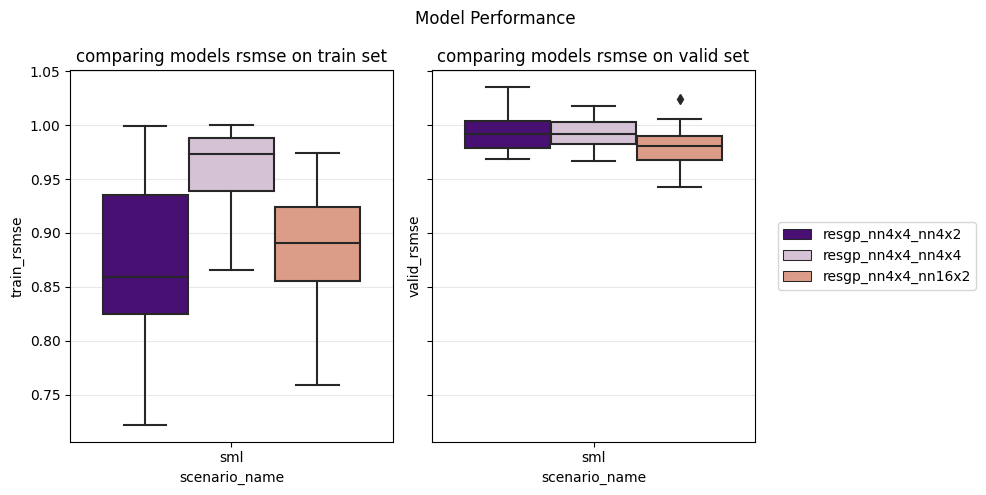

,method,scenario_name,valid_rsmse_mean,valid_rsmse_min,valid_rsmse_max,valid_rsmse_median
0,resgp_nn4x4_nn16x2,sml,0.978444,0.942412,1.024244,0.980530
1,resgp_nn4x4_nn4x2,sml,0.993432,0.968482,1.035216,0.991953
2,resgp_nn4x4_nn4x4,sml,0.992133,0.966317,1.018134,0.991703


In [9]:
clients_train_data = None
if mode in ['vanilla', 'meta_fedavg']:
    clients_train_data = []
    for d in env_dict['train_scenarios'][scenario_name_fl]['clients_data']:
        clients_train_data.append((d[0], d[1]))

# ---------- Load Trained Models ----------
filename_res = os.path.join(os.getcwd(), "saved_results", exp_name, mode)
models_all_resgp, results_all_resgp = load_trained_models(
    mode=mode, methods=methods, ts_data=ts_data,
    filename_res=filename_res+'_'+scenario_name_fl,
    clients_train_data=clients_train_data)


# ----------       BOX PLOTS      ----------
# perf_box_plots(env_dict, criterion='nll', methods=methods, results_all=results_all_resgp)
# perf_box_plots(env_dict, criterion='calibr', methods=methods, results_all=results_all_resgp)
perf_box_plots(env_dict, criterion='rsmse', methods=methods, results_all=results_all_resgp)



[INFO] results of method nn16_nonar loaded.

[INFO] results of method lingp loaded.

[INFO] results of method nn4x4 loaded.

[INFO] results of method nn44 loaded.

[INFO] results of method nn4x6 loaded.

[INFO] results of method nn8x4 loaded.

[INFO] results of method nn4444 loaded.

[INFO] results of method nn16 loaded.
[WARNING] The input matches the stored training data. Did you forget to call model.train()? GPInputWarning
in file/home/mahrokhg/anaconda3/envs/python3/lib/python3.10/site-packages/gpytorch/models/exact_gp.py at line number:274


[WARNING] The input matches the stored training data. Did you forget to call model.train()? GPInputWarning
in file/home/mahrokhg/anaconda3/envs/python3/lib/python3.10/site-packages/gpytorch/models/exact_gp.py at line number:274

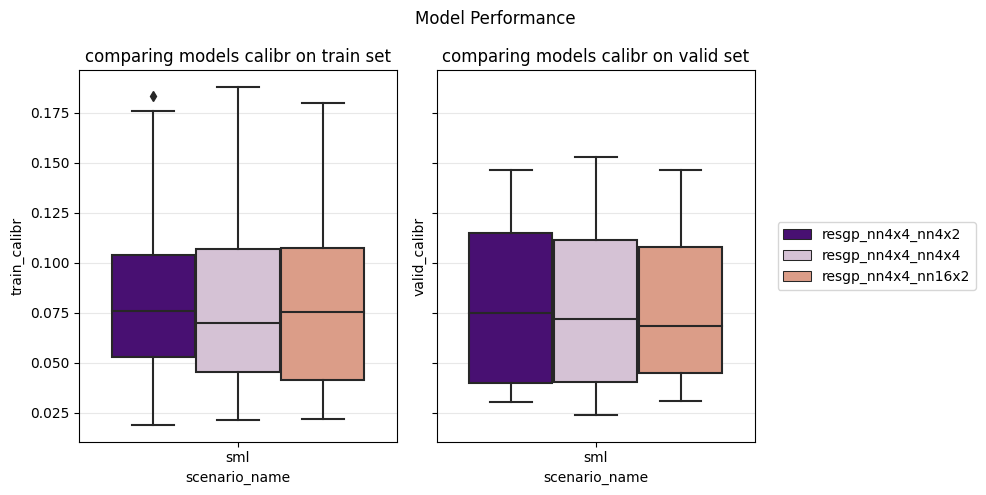

,method,scenario_name,valid_calibr_mean,valid_calibr_min,valid_calibr_max,valid_calibr_median
0,resgp_nn4x4_nn16x2,sml,0.078943,0.031094,0.146623,0.068509
1,resgp_nn4x4_nn4x2,sml,0.080160,0.030224,0.146338,0.074996
2,resgp_nn4x4_nn4x4,sml,0.079212,0.023720,0.153002,0.071771


In [10]:
filename_res = os.path.join(os.getcwd(), "saved_results", exp_name, 'global') # NOTE
models_mean, _ = load_trained_models(
    mode='ours', methods=None, ts_data=ts_data,
    filename_res=filename_res+'_'+scenario_name_fl)

# --- calibration ---
for met in results_all_resgp.keys():
    if results_all_resgp[met] is None:
        continue
    assert list(results_all_resgp[met].keys()) == [scenario_name_fl]
    # 1. select mean model
    mean_method = met.split('_')[1]
    model_mean = models_mean[mean_method][scenario_name_fl][criteria[0]]

    # 2. calculate env_dict_res
    env_dict_res = copy.deepcopy(env_dict)
    del env_dict_res['train_scenarios'][scenario_name_fl]['time_series']
    res_train_std, res_valid_std = np.zeros(num_clients), np.zeros(num_clients)
    res_train_mean, res_valid_mean = np.zeros(num_clients), np.zeros(num_clients)
    for client_num in np.arange(num_clients):
        x_train, y_train, x_valid, y_valid = env_dict['train_scenarios'][scenario_name_fl]['clients_data'][client_num]
        # residual of train
        y_train_pred, _ = model_mean.predict(x_train, y_train, x_train)
        y_valid_pred, _ = model_mean.predict(x_train, y_train, x_valid)
        y_train_pred = y_train_pred.reshape(y_train.shape)
        y_valid_pred = y_valid_pred.reshape(y_valid.shape)
        data_tup = (x_train, 
                    y_train-y_train_pred,
                    x_valid,
                    y_valid-y_valid_pred)

        env_dict_res['train_scenarios'][scenario_name_fl]['clients_data'][client_num] = data_tup


    # 3. calibr
    model = models_all_resgp[met][scenario_name_fl]['rsmse']
    data_tups = env_dict_res['train_scenarios'][scenario_name_fl]['clients_data'] # Note
    # update train
    train_data = [(d[0], d[1], d[0], d[1]) for d in data_tups]
    results_all_resgp[met][scenario_name_fl]['calibr'] = {
        'criterion_train': model.eval_datasets(train_data, get_full_list=True)['calibr'],
        # update valid
        'criterion_valid': model.eval_datasets(data_tups, get_full_list=True)['calibr']
    }

perf_box_plots(env_dict, criterion='calibr', methods=methods, results_all=results_all_resgp)


TypeError: 'NoneType' object is not subscriptable

# combine with mean model



----- loading shared (shared_nn) models -----

[INFO] results of method nn16_nonar loaded.

[INFO] results of method lingp loaded.

[INFO] results of method nn4x4 loaded.

[INFO] results of method nn44 loaded.

[INFO] results of method nn4x6 loaded.

[INFO] results of method nn8x4 loaded.

[INFO] results of method nn4444 loaded.

[INFO] results of method nn16 loaded.


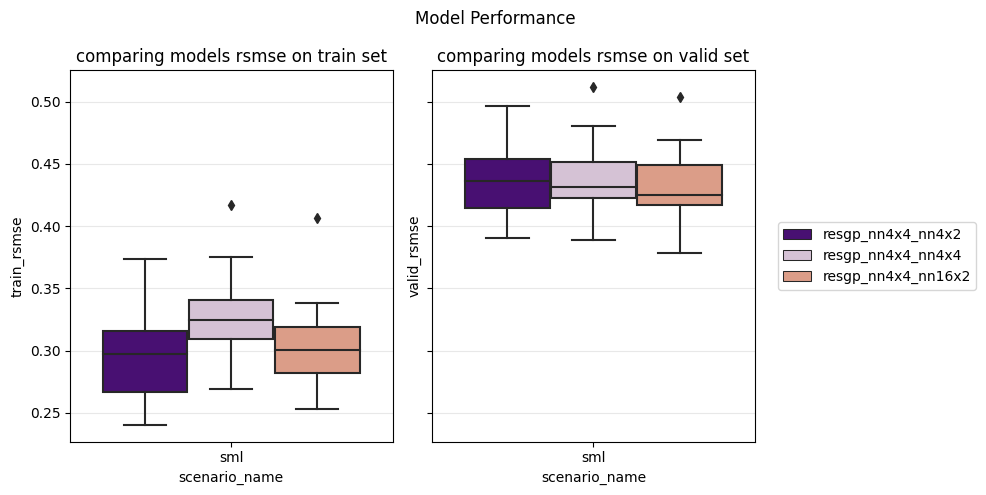

,method,scenario_name,valid_rsmse_mean,valid_rsmse_min,valid_rsmse_max,valid_rsmse_median
0,resgp_nn4x4_nn16x2,sml,0.429943,0.378309,0.503815,0.424637
1,resgp_nn4x4_nn4x2,sml,0.436542,0.390493,0.496287,0.436250
2,resgp_nn4x4_nn4x4,sml,0.435960,0.388656,0.511551,0.431319


In [12]:
# shared_nn models
print('\n\n----- loading shared (shared_nn) models -----')
models_shared_nn, results_shared_nn = load_trained_models(
    mode='ours', ts_data=ts_data,
    filename_res=os.path.join(os.getcwd(), "saved_results", exp_name, 'global_'+scenario_name_fl)
 )   

# combine with mean nn
results_ours_comb = copy.deepcopy(results_all_resgp)
for met in results_all_resgp.keys():
    if results_all_resgp[met] is None:
        continue
    # set rsmse
    for train_scenario in results_ours_comb[met].keys():
        for valid_or_train in results_all_resgp[met][train_scenario]['rsmse'].keys():
            if valid_or_train.startswith('criterion'):
                arr1 = np.array(results_all_resgp[met][train_scenario]['rsmse'][valid_or_train])
                arr2 = np.array(results_shared_nn[met.split('_')[1]][train_scenario]['rsmse'][valid_or_train])
                results_ours_comb[met][train_scenario]['rsmse'][valid_or_train] = arr1 * arr2
        # TODO: how to combine other metrics?

perf_box_plots(env_dict, criterion='rsmse', methods=methods, results_all=results_ours_comb)


In [13]:
# get quantiles
# tmp = results_ours_comb['resgp_nn32_nn16']['1y']['rsmse']['criterion_valid']
# print(np.quantile(tmp, 0.25),np.quantile(tmp, 0.5), np.quantile(tmp, 0.75))

TypeError: 'NoneType' object is not subscriptable